**1. CLEAN DATASET**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. ĐỌC DỮ LIỆU
# ---------------------------------------------------------
df = pd.read_csv('CKD_NHANES_2021_2023.csv', delimiter=';')

# ---------------------------------------------------------
# 2. LỌC DỮ LIỆU VÀ CHỌN BIẾN
# ---------------------------------------------------------
# Chỉ lấy người bị chẩn đoán tiểu đường
diabetic_df = df[df['diabetes_diagnosed'] == 1.0].copy()

# Chọn các biến đưa vào nghiên cứu
vars_of_interest = ['ckd_present','age', 'gender', 'bmi',
                    'bp_systolic', 'bp_diastolic',        # Huyết áp toàn diện
                    'blood_urea_nitrogen', 'uric_acid',   # Chỉ số xét nghiệm máu
                    'ever_smoked','insulin_use', 'diabetes_pills']
data = diabetic_df[vars_of_interest].copy()

# ---------------------------------------------------------
# 3. TIỀN XỬ LÝ DỮ LIỆU (PREPROCESSING)
# ---------------------------------------------------------
# a. Chuyển các biến liên tục sang dạng số
continuous_cols = ['age', 'bmi', 'bp_systolic', 'bp_diastolic', 'blood_urea_nitrogen', 'uric_acid']
for col in continuous_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Tạo biến Pulse Pressure (Áp lực mạch)
data['pulse_pressure'] = data['bp_systolic'] - data['bp_diastolic']

# Tạo biến MAP (Huyết áp động mạch trung bình)
data['map'] = data['bp_diastolic'] + (data['pulse_pressure'] / 3)

# b. Mã hóa Giới tính (Dummy variable)
data['gender_male'] = data['gender'].map({'Male': 1, 'Female': 0})
data = data.drop('gender', axis=1)

# c. Xử lý biến Hút thuốc (NHANES coding: 1=Yes, 2=No, 9=Refused)
# Chuyển thành Nhị phân: 1 = Hút thuốc, 0 = Không hút thuốc
data['ever_smoked'] = data['ever_smoked'].replace({2.0: 0.0, 9.0: np.nan})

print("--- SỐ LƯỢNG MISSING VALUES ---")
print(data.isnull().sum())

# d. Xử lý Missing Value bằng Listwise Deletion (Xóa dòng chứa NA)
data_clean = data.dropna()
original_count = len(data)
clean_count = len(data_clean)

print("\n--- MÔ TẢ DỮ LIỆU SAU KHI TIỀN XỬ LÝ ---")
print(data_clean.describe().round(2))

print("\n--- THỐNG KÊ DỮ LIỆU SAU KHI LÀM SẠCH ---")
print(f"Số lượng bệnh nhân ban đầu: {original_count}")
print(f"Số lượng bệnh nhân giữ lại: {clean_count} (Đạt {clean_count/original_count*100:.1f}%)")

# =========================================================
# 4. LƯU (XUẤT) FILE DỮ LIỆU ĐÃ LÀM SẠCH RA CSV
# =========================================================
# index=False giúp bỏ cột số thứ tự (0, 1, 2...) khi lưu file
data_clean.to_csv('CKD_diabetic_cleaned.csv', index=False)
print("\n[THÀNH CÔNG] Đã lưu dữ liệu tiền xử lý ra file: 'CKD_diabetic_cleaned.csv'")

--- SỐ LƯỢNG MISSING VALUES ---
ckd_present              0
age                      0
bmi                    231
bp_systolic            234
bp_diastolic           234
blood_urea_nitrogen    315
uric_acid              315
ever_smoked             11
insulin_use              0
diabetes_pills           0
pulse_pressure         234
map                    234
gender_male              0
dtype: int64

--- MÔ TẢ DỮ LIỆU SAU KHI TIỀN XỬ LÝ ---
       ckd_present     age     bmi  bp_systolic  bp_diastolic  \
count       730.00  730.00  730.00       730.00        730.00   
mean          0.66   63.02   32.91       126.90         74.33   
std           0.48   12.15    7.68        19.35         12.09   
min           0.00   18.00   18.10        80.00         37.00   
25%           0.00   57.00   27.50       114.00         66.00   
50%           1.00   64.00   31.90       125.00         74.00   
75%           1.00   72.00   37.08       137.75         82.00   
max           1.00   80.00   64.70       2

**2. EDA - KHÁM PHÁ DỮ LIỆU**

/tmp/ipykernel_8462/2396967289.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='ckd_present', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_8462/2396967289.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='ckd_present', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_8462/2396967289.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='ckd_present', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_8462/2396967289.py:23: FutureWarning: 

Passing `palette` without assigning `hu

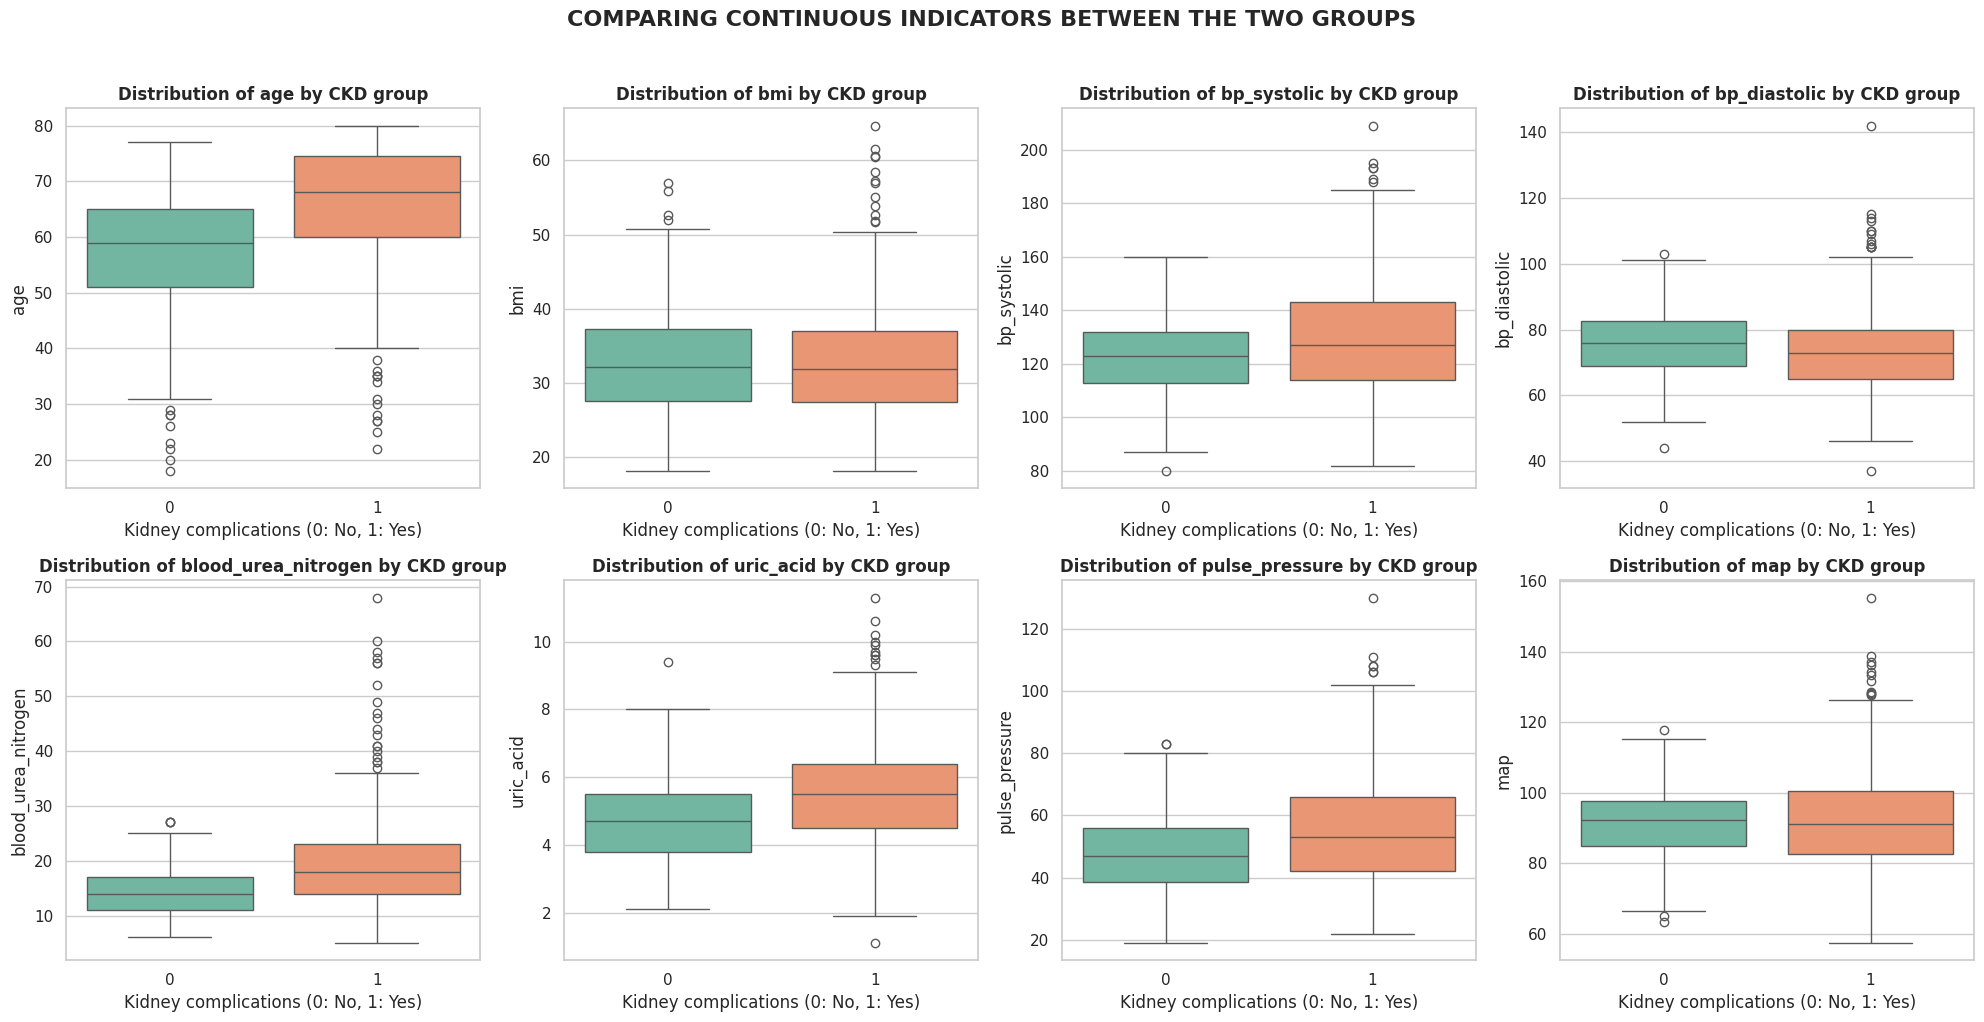

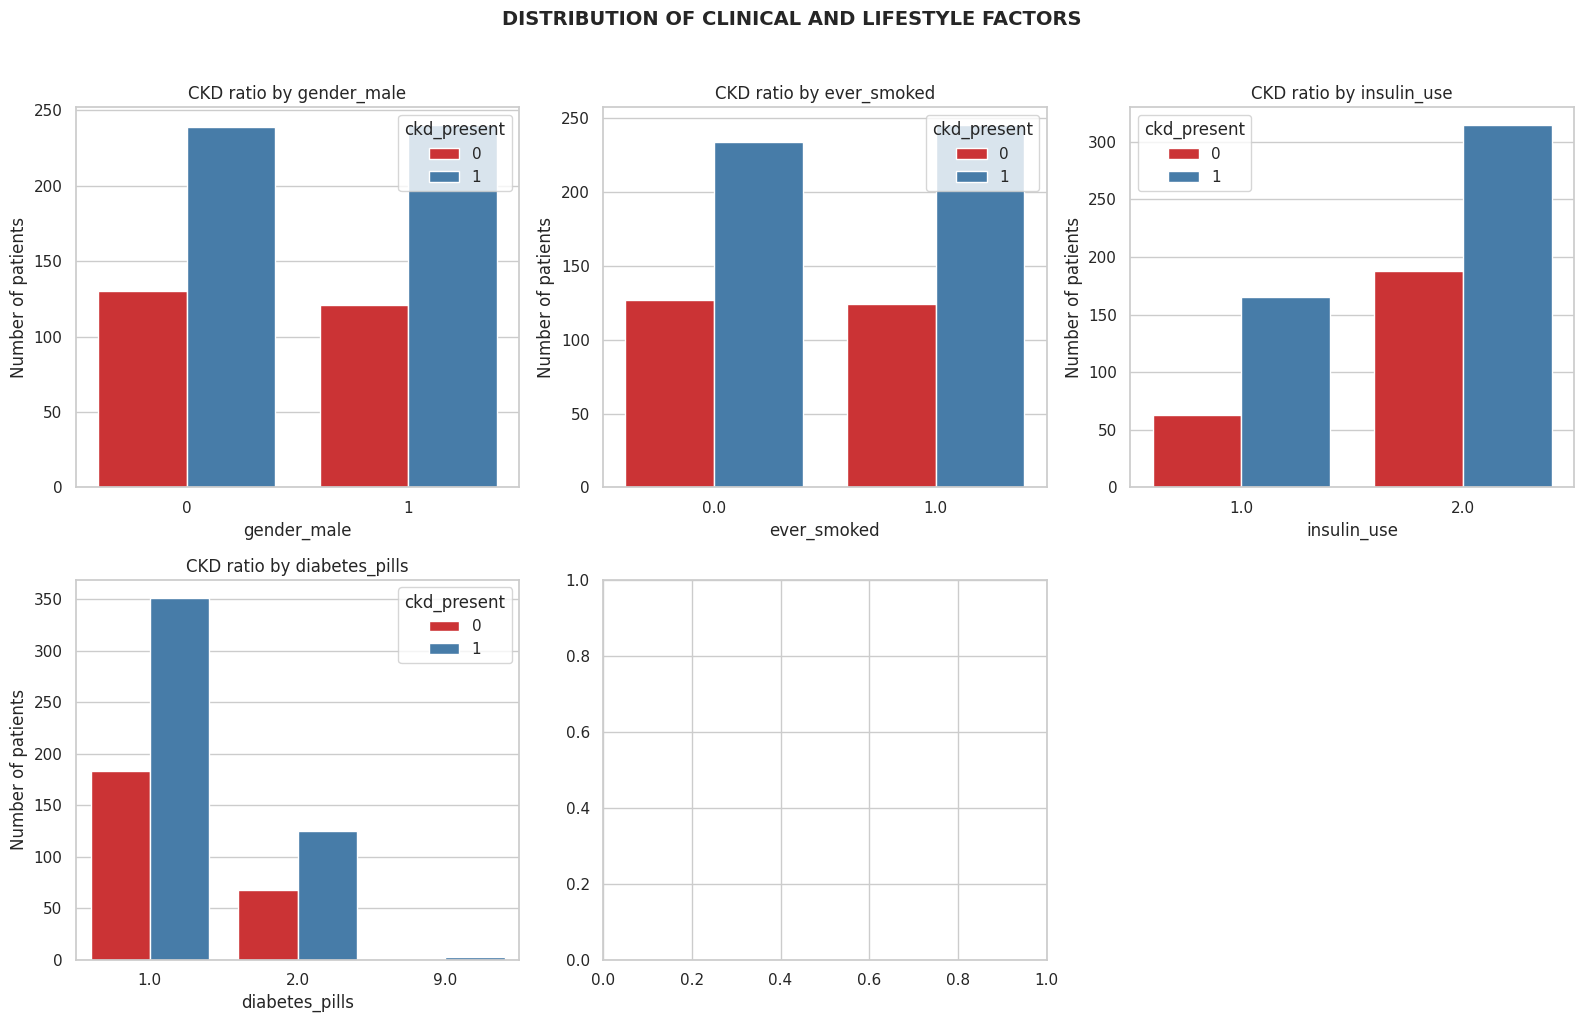

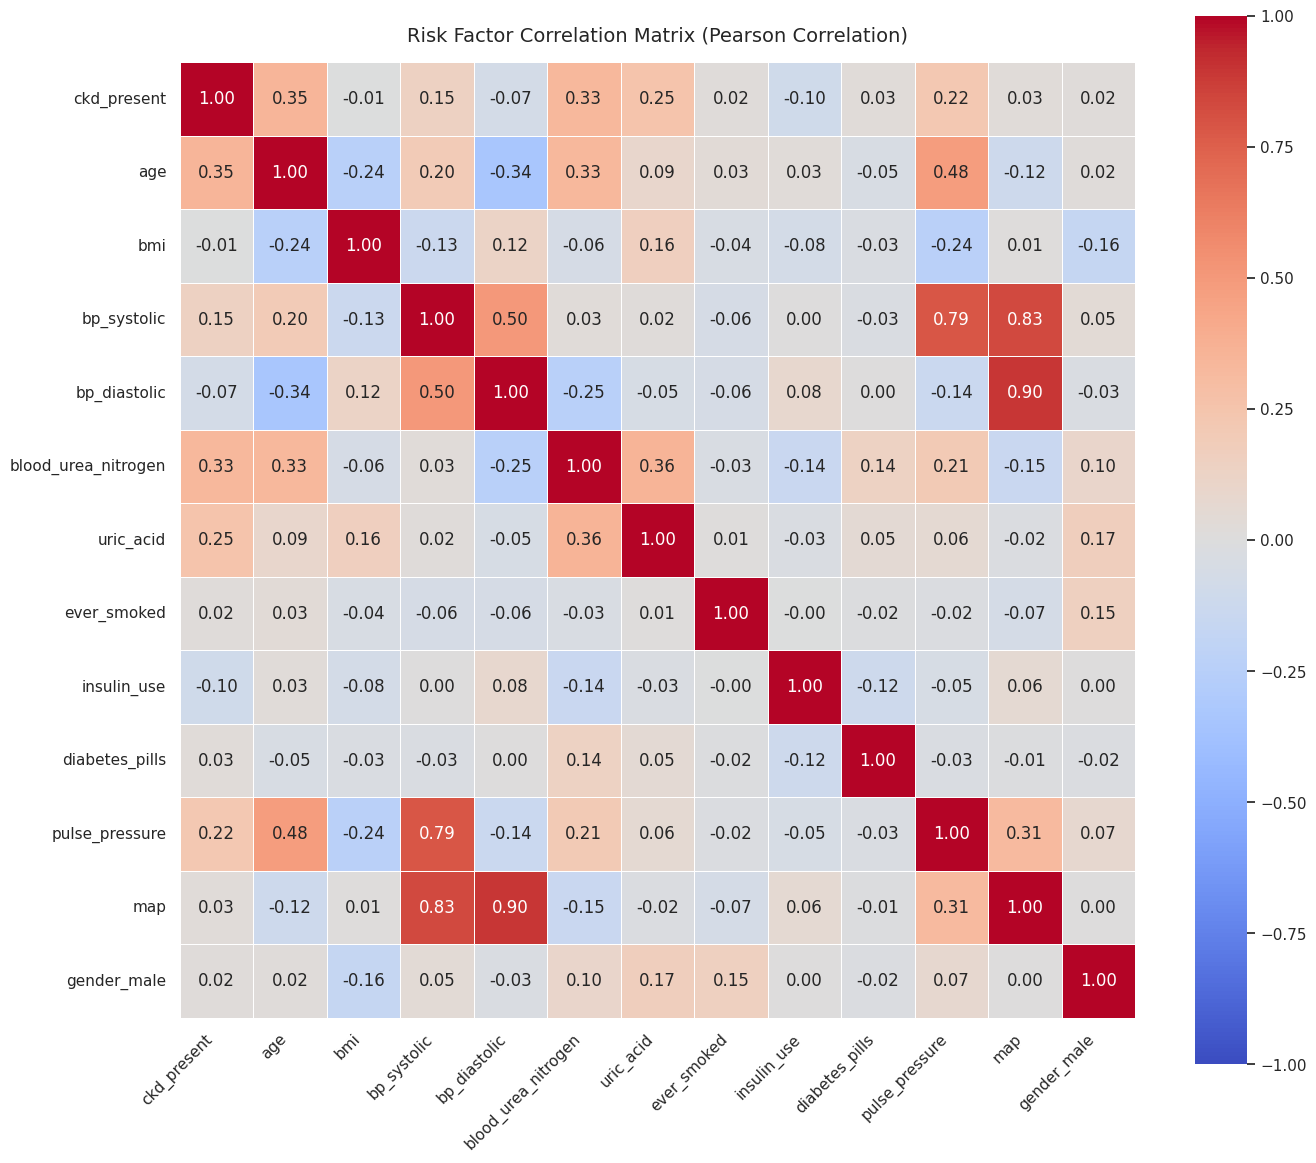

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu sạch
# Lưu ý: 'gender' đã được bạn đổi thành 'gender_male' ở bước tiền xử lý
df_clean = pd.read_csv('CKD_diabetic_cleaned.csv')

# Phân loại các nhóm biến
num_cols = ['age', 'bmi', 'bp_systolic', 'bp_diastolic', 'blood_urea_nitrogen', 'uric_acid', 'pulse_pressure', 'map']
cat_cols = ['gender_male', 'ever_smoked', 'insulin_use', 'diabetes_pills']

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# BIỂU ĐỒ 1: BOXPLOT CHO CÁC BIẾN LIÊN TỤC
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten() # Trải phẳng ma trận 2x4 thành mảng 1 chiều để dễ đưa vào vòng lặp

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_clean, x='ckd_present', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {col} by CKD group', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Kidney complications (0: No, 1: Yes)')

plt.suptitle('COMPARING CONTINUOUS INDICATORS BETWEEN THE TWO GROUPS', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('EDA_Continuous.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# BIỂU ĐỒ 2: COUNTPLOT CHO CÁC BIẾN PHÂN LOẠI
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df_clean, x=col, hue='ckd_present', ax=axes[i], palette='Set1')
    axes[i].set_title(f'CKD ratio by {col}', fontsize=12)
    axes[i].set_ylabel('Number of patients')

# Ẩn ô biểu đồ thứ 6 bị thừa (vì chỉ có 5 biến categorical)
fig.delaxes(axes[5])
plt.suptitle('DISTRIBUTION OF CLINICAL AND LIFESTYLE FACTORS', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('EDA_Categorical.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# BIỂU ĐỒ 3: MA TRẬN TƯƠNG QUAN TỔNG THỂ (ALL FEATURES)
# ---------------------------------------------------------
# 4. MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX)
# ---------------------------------------------------------
corr_matrix = data_clean.corr()

# Vẽ biểu đồ Heatmap cho ma trận tương quan
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix,
            annot=True,          # Hiển thị số
            cmap='coolwarm',     # Thang màu Đỏ (Tương quan thuận) - Xanh (Tương quan nghịch)
            fmt=".2f",           # Lấy 2 chữ số thập phân
            vmin=-1, vmax=1,
            linewidths=0.5,
            square=True)

plt.title('Risk Factor Correlation Matrix (Pearson Correlation)', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Lưu biểu đồ
plt.savefig('correlation_matrix_cleaned.png', dpi=300)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency
from IPython.display import display, HTML

# =========================================================
# 1. ĐỌC DỮ LIỆU & FEATURE ENGINEERING
# =========================================================
df = pd.read_csv('CKD_NHANES_2021_2023.csv', delimiter=';')
diabetic_df = df[df['diabetes_diagnosed'] == 1.0].copy()

vars_of_interest = [
    'ckd_present', 'age', 'gender', 'bmi', 'bp_systolic', 'bp_diastolic',
    'blood_urea_nitrogen', 'uric_acid', 'ever_smoked', 'insulin_use',
    'diabetes_pills'
]
data = diabetic_df[vars_of_interest].copy()

# Ép kiểu số
cont_cols = ['age', 'bmi', 'bp_systolic', 'bp_diastolic', 'blood_urea_nitrogen', 'uric_acid']
for col in cont_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Tạo 2 biến mới
data['pulse_pressure'] = data['bp_systolic'] - data['bp_diastolic']
data['map'] = data['bp_diastolic'] + (data['pulse_pressure'] / 3)

# Xử lý biến phân loại
data['gender_male'] = data['gender'].map({'Male': 1, 'Female': 0})
data = data.drop('gender', axis=1)

data['ever_smoked'] = data['ever_smoked'].replace({2.0: 0.0, 9.0: np.nan})
data['insulin_use'] = data['insulin_use'].replace({2.0: 0.0})
data['diabetes_pills'] = data['diabetes_pills'].replace({2.0: 0.0, 9.0: np.nan})

# Dữ liệu sạch
data_clean = data.dropna()

group0 = data_clean[data_clean['ckd_present'] == 0]
group1 = data_clean[data_clean['ckd_present'] == 1]
n0, n1 = len(group0), len(group1)

# =========================================================
# 2. ĐỊNH NGHĨA TÊN BIẾN HIỂN THỊ
# =========================================================
var_names = {
    'age': 'Age (years)',
    'bmi': 'BMI (kg/m²)',
    'bp_systolic': 'Systolic BP (mmHg)',
    'bp_diastolic': 'Diastolic BP (mmHg)',
    'pulse_pressure': 'Pulse Pressure (mmHg)',
    'map': 'Mean Arterial Pressure (mmHg)',
    'blood_urea_nitrogen': 'Blood Urea Nitrogen (mg/dL)',
    'uric_acid': 'Uric Acid (mg/dL)',
    'gender_male': 'Gender (Male)',
    'ever_smoked': 'Ever Smoked',
    'insulin_use': 'Insulin Use',
    'diabetes_pills': 'Diabetes Pills',
  }

results = []
cont_vars = ['age', 'bmi', 'bp_systolic', 'bp_diastolic', 'pulse_pressure', 'map', 'blood_urea_nitrogen', 'uric_acid']
cat_vars = ['gender_male', 'ever_smoked', 'insulin_use', 'diabetes_pills']

# =========================================================
# 3. TÍNH TOÁN VÀ LƯU VÀO BẢNG
# =========================================================
# Xử lý biến liên tục
for var in cont_vars:
    m0, s0 = group0[var].mean(), group0[var].std()
    m1, s1 = group1[var].mean(), group1[var].std()
    _, p = ttest_ind(group0[var], group1[var], equal_var=False)

    # Đổi màu đỏ cho P-value in đậm
    p_str = f"<b style='color: red;'><0.001</b>" if p < 0.001 else (f"<b style='color: red;'>{p:.3f}</b>" if p < 0.05 else f"{p:.3f}")

    results.append({
        'Features': f"{var_names[var]}", # Bỏ in đậm
        f'Without CKD (N={n0})': f"{m0:.1f} ± {s0:.1f}",
        f'With CKD (N={n1})': f"{m1:.1f} ± {s1:.1f}",
        'P-value': p_str
    })

# Xử lý biến phân loại
for var in cat_vars:
    ct = pd.crosstab(data_clean[var], data_clean['ckd_present'])
    _, p, _, _ = chi2_contingency(ct)

    p_str = f"<b style='color: red;'><0.001</b>" if p < 0.001 else (f"<b style='color: red;'>{p:.3f}</b>" if p < 0.05 else f"{p:.3f}")

    # Dòng tiêu đề biến phân loại (vẫn giữ in đậm để làm tiêu đề nhóm)
    results.append({
        'Features': f"<b>{var_names[var]}</b>",
        f'Without CKD (N={n0})': "",
        f'With CKD (N={n1})': "",
        'P-value': p_str
    })

    # Dòng mức độ (levels)
    for val in sorted(data_clean[var].unique()):
        c0 = len(group0[group0[var] == val])
        p0 = (c0 / n0) * 100 if n0 > 0 else 0
        c1 = len(group1[group1[var] == val])
        p1 = (c1 / n1) * 100 if n1 > 0 else 0

        # Đổi tên thành Yes (1) / No (0)
        if var in ['gender_male', 'ever_smoked', 'insulin_use', 'diabetes_pills']:
            val_label = "Yes (1)" if val == 1.0 else "No (0)"
        else:
            val_label = f"Level {int(val)}"

        results.append({
            'Features': f"&nbsp;&nbsp;&nbsp;&nbsp;{val_label}", # Thụt lề
            f'Without CKD (N={n0})': f"{c0} ({p0:.1f}%)",
            f'With CKD (N={n1})': f"{c1} ({p1:.1f}%)",
            'P-value': ""
        })

# =========================================================
# 4. XUẤT RA HTML (PHONG CÁCH KẺ Ô & MÀU XANH XEN KẼ)
# =========================================================
df_final = pd.DataFrame(results)

# Chuyển Dataframe thành bảng HTML thô, escape=False để render được màu và in đậm
raw_html = df_final.to_html(escape=False, index=False)

# ĐÃ CẬP NHẬT: CSS mới tạo lưới kẻ ô và màu xanh xen kẽ (Zebra-striping)
css_style = """
<style>
    .grid-table {
        border-collapse: collapse;
        width: 100%;
        font-family: Arial, sans-serif;
        font-size: 14px;
        text-align: left;
        border: 1px solid #b0c4de; /* Viền bao quanh bảng */
    }
    .grid-table th {
        border: 1px solid #b0c4de; /* Kẻ ô tiêu đề */
        padding: 12px;
        background-color: #2F5597; /* Nền xanh đậm chuẩn báo cáo */
        color: white;
        text-align: center;
    }
    .grid-table td {
        padding: 8px 12px;
        border: 1px solid #b0c4de; /* Kẻ ô nội dung */
    }
    /* Dòng màu xanh nhạt xen kẽ */
    .grid-table tr:nth-child(odd) {
        background-color: #e9edf4;
    }
    /* Dòng nền trắng */
    .grid-table tr:nth-child(even) {
        background-color: #ffffff;
    }
    /* Hiệu ứng di chuột đổi màu */
    .grid-table tr:hover {
        background-color: #d0d9e8;
    }
    .compact-table {
        border-collapse: collapse;
        width: auto; /* Tự động co lại theo nội dung */
        margin: 20px 0;
        font-family: Arial, sans-serif;
        font-size: 13px; /* Giảm nhẹ cỡ chữ */
        border: 1px solid #b0c4de;
    }
    .compact-table th {
        border: 1px solid #b0c4de;
        padding: 8px 15px; /* Giảm đệm để thu hẹp cột */
        background-color: #2F5597;
        color: white;
        text-align: center;
    }
    .compact-table td {
        padding: 5px 12px; /* Thu hẹp chiều cao và chiều ngang ô */
        border: 1px solid #b0c4de;
    }
    .compact-table tr:nth-child(odd) { background-color: #f2f5f9; }
    .compact-table tr:nth-child(even) { background-color: #ffffff; }
</style>
"""

# Áp dụng CSS vào bảng
final_html = css_style + raw_html.replace('<table border="1" class="dataframe">', '<table class="grid-table">')

# Hiển thị trực tiếp trên Colab
display(HTML(final_html))

# Lưu file để copy ra Word
with open('Table1_GridStyle.html', 'w', encoding='utf-8') as f:
    f.write(final_html)

print("--- THÀNH CÔNG ---")
print("Bảng đã được cập nhật giao diện: Kẻ ô đầy đủ và tô dòng màu xanh đan xen!")



Features,Without CKD (N=251),With CKD (N=476),P-value
Age (years),57.2 ± 11.7,66.0 ± 11.3,<0.001
BMI (kg/m²),33.0 ± 7.5,32.9 ± 7.8,0.895
Systolic BP (mmHg),123.0 ± 14.8,129.0 ± 21.1,<0.001
Diastolic BP (mmHg),75.6 ± 9.9,73.7 ± 13.0,0.030
Pulse Pressure (mmHg),47.4 ± 12.8,55.3 ± 18.1,<0.001
Mean Arterial Pressure (mmHg),91.4 ± 10.1,92.1 ± 13.8,0.418
Blood Urea Nitrogen (mg/dL),14.1 ± 4.1,19.5 ± 8.6,<0.001
Uric Acid (mg/dL),4.7 ± 1.3,5.5 ± 1.5,<0.001
Gender (Male),,,0.703
No (0),130 (51.8%),238 (50.0%),


--- THÀNH CÔNG ---
Bảng đã được cập nhật giao diện: Kẻ ô đầy đủ và tô dòng màu xanh đan xen!


**2. TRAIN/TEST SPLIT & SCALING**

In [ ]:
# =========================================================
# CHIA TẬP TRAIN/TEST VÀ CHUẨN HÓA
# =========================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Đọc lại file dữ liệu sạch vừa lưu ở trên
df_clean = pd.read_csv('CKD_diabetic_cleaned.csv')

# 2. Tách biến độc lập (X) và biến mục tiêu (y)
X = df_clean.drop('ckd_present', axis=1)
y = df_clean['ckd_present']

# 3. Chia tập Train/Test (stratify=y giúp cân bằng tỷ lệ người bệnh ở 2 tập)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Chuẩn hóa dữ liệu (Scaling)
num_cols = ['age', 'bmi', 'bp_systolic', 'bp_diastolic','blood_urea_nitrogen', 'uric_acid','pulse_pressure', 'map']
scaler = StandardScaler()

# Tạo bản sao để tránh cảnh báo
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit trên Train và Transform trên cả Train/Test
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("[THÀNH CÔNG] Đã chia tập và chuẩn hóa xong!")
print(f"Kích thước tập Train: {X_train_scaled.shape}")
print(f"Kích thước tập Test: {X_test_scaled.shape}")

[THÀNH CÔNG] Đã chia tập và chuẩn hóa xong!
Kích thước tập Train: (584, 12)
Kích thước tập Test: (146, 12)


**3. MODEL TRAINING**

In [ ]:
# =========================================================
# HUẤN LUYỆN 3 MÔ HÌNH
# =========================================================
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

print("Đang huấn luyện các mô hình...")

# 1. Logistic Regression (Xử lý mất cân bằng bằng class_weight)
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

# 2. XGBoost (Xử lý mất cân bằng bằng scale_pos_weight)
ratio = (len(y_train) - sum(y_train)) / sum(y_train) if sum(y_train) > 0 else 1
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=ratio, random_state=42)
xgb.fit(X_train_scaled, y_train)

# 3. MLP Neural Network (Mạng nơ-ron nhân tạo)
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)

print("[THÀNH CÔNG] Cả 3 mô hình đã học xong dữ liệu!")

Đang huấn luyện các mô hình...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:00:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[THÀNH CÔNG] Cả 3 mô hình đã học xong dữ liệu!


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


**4. ROC - EVALUATION**

Đang huấn luyện 3 mô hình...

=== Logistic Regression ===
Accuracy: 70.51% | AUC Score: 0.7980
              precision    recall  f1-score   support

           0       0.44      0.70      0.54        53
           1       0.88      0.71      0.78       164

    accuracy                           0.71       217
   macro avg       0.66      0.70      0.66       217
weighted avg       0.77      0.71      0.72       217

-------------------------------------------------------
=== MLP Neural Network ===
Accuracy: 73.73% | AUC Score: 0.7479
              precision    recall  f1-score   support

           0       0.46      0.43      0.45        53
           1       0.82      0.84      0.83       164

    accuracy                           0.74       217
   macro avg       0.64      0.63      0.64       217
weighted avg       0.73      0.74      0.73       217

-------------------------------------------------------
=== XGBoost ===
Accuracy: 76.50% | AUC Score: 0.8316
              precisio

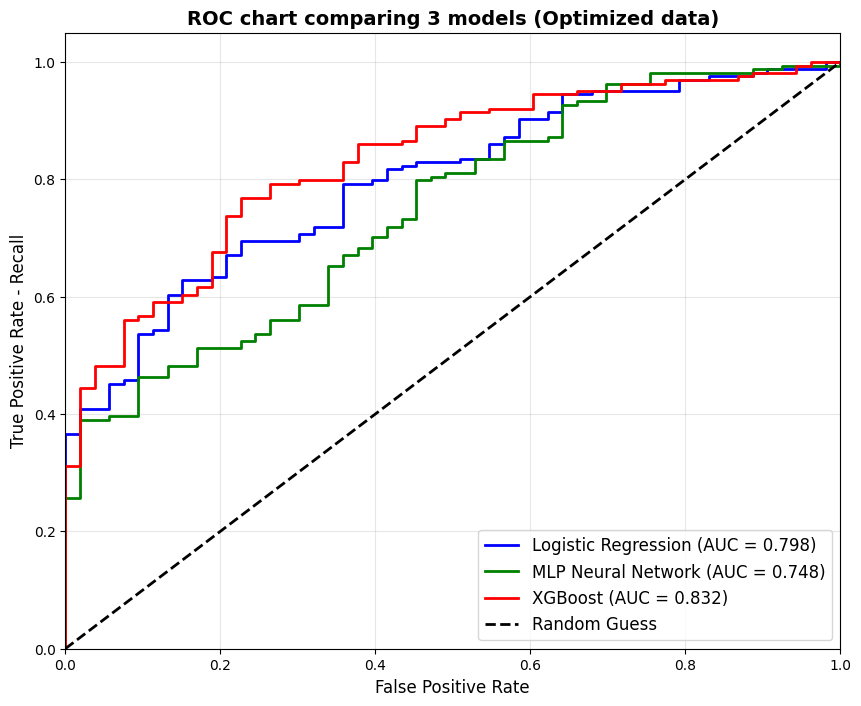

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

# =====================================================================
# BƯỚC 1: ĐỌC DỮ LIỆU & LỌC BIẾN (Chưa xóa dòng khuyết thiếu)
# =====================================================================
df = pd.read_csv('CKD_NHANES_2021_2023.csv', delimiter=';')
diabetic_df = df[df['diabetes_diagnosed'] == 1.0].copy()

# Chọn các biến cốt lõi
vars_of_interest = ['ckd_present', 'age', 'gender', 'bmi',
                    'bp_systolic', 'bp_diastolic', 'blood_urea_nitrogen',
                    'uric_acid', 'ever_smoked', 'insulin_use', 'diabetes_pills']
data = diabetic_df[vars_of_interest].copy()

# Mã hóa
data['gender_male'] = data['gender'].map({'Male': 1, 'Female': 0})
data = data.drop('gender', axis=1)
data['ever_smoked'] = data['ever_smoked'].replace({2.0: 0.0, 9.0: np.nan})

# Ép kiểu số
for col in ['age', 'bmi', 'bp_systolic', 'bp_diastolic', 'blood_urea_nitrogen', 'uric_acid']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Bắt buộc xóa các dòng không có nhãn (ckd_present)
data = data.dropna(subset=['ckd_present'])

X = data.drop('ckd_present', axis=1)
y = data['ckd_present']

# =====================================================================
# BƯỚC 2: CHIA TẬP & NỘI SUY KNN (Tránh Data Leakage)
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Cứu dữ liệu bằng KNN
imputer = KNNImputer(n_neighbors=5)
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Feature Engineering (Tạo biến sau khi đã điền khuyết)
for df_temp in [X_train_imp, X_test_imp]:
    df_temp['pulse_pressure'] = df_temp['bp_systolic'] - df_temp['bp_diastolic']
    df_temp['map'] = df_temp['bp_diastolic'] + (df_temp['pulse_pressure'] / 3)

# =====================================================================
# BƯỚC 3: LOG TRANSFORM & ROBUST SCALING
# =====================================================================
# Log hóa để giảm lệch phải cho BUN và Uric Acid
for feat in ['blood_urea_nitrogen', 'uric_acid']:
    X_train_imp[feat] = np.log1p(X_train_imp[feat])
    X_test_imp[feat] = np.log1p(X_test_imp[feat])

# Chuẩn hóa
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

# Chỉ dùng SMOTE cho MLP
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# =====================================================================
# BƯỚC 4: HUẤN LUYỆN 3 MÔ HÌNH
# =====================================================================
print("Đang huấn luyện 3 mô hình...\n")

# 1. Logistic Regression (Baseline) - Dùng class_weight
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 2. MLP Neural Network - Học trên dữ liệu SMOTE
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                    alpha=0.05, max_iter=1500, random_state=42)
mlp.fit(X_train_smote, y_train_smote)

# 3. XGBoost - Dùng scale_pos_weight
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
xgb = XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=4,
                    scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)

# =====================================================================
# BƯỚC 5: ĐÁNH GIÁ & SO SÁNH (VẼ ĐƯỜNG CONG ROC)
# =====================================================================
models = {'Logistic Regression': log_reg, 'MLP Neural Network': mlp, 'XGBoost': xgb}
colors = {'Logistic Regression': 'blue', 'MLP Neural Network': 'green', 'XGBoost': 'red'}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Dự đoán
    y_preds = model.predict(X_test_scaled)
    y_probs = model.predict_proba(X_test_scaled)[:, 1]

    # Tính điểm
    acc = accuracy_score(y_test, y_preds)
    auc = roc_auc_score(y_test, y_probs)

    print(f"=== {name} ===")
    print(f"Accuracy: {acc*100:.2f}% | AUC Score: {auc:.4f}")
    print(classification_report(y_test, y_preds))
    print("-" * 55)

    # Vẽ ROC
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=colors[name], lw=2)

# Trang trí biểu đồ ROC

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate - Recall', fontsize=12)
plt.title('ROC chart comparing 3 models (Optimized data)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.savefig('Comparison_ROC_Curve.png', dpi=300)
plt.show()

**5. FEATURE IMPORTANCE & ODDS RATIO**

=== BẢNG ODDS RATIO (MỨC ĐỘ TĂNG NGUY CƠ) ===
        Yếu tố lâm sàng  Odds Ratio
4   blood_urea_nitrogen    2.394482
0                   age    1.990261
5             uric_acid    1.637248
6           ever_smoked    1.240858
2           bp_systolic    1.129137
10                  map    1.129052
8        diabetes_pills    1.123350
3          bp_diastolic    1.098543
1                   bmi    1.088682
9        pulse_pressure    1.075363
11          gender_male    0.667364
7           insulin_use    0.630216
--------------------------------------------------
* Gợi ý đọc: Nếu ever_smoked có Odds Ratio = 1.3, nghĩa là người hút thuốc có rủi ro mắc CKD cao gấp 1.3 lần người không hút thuốc.



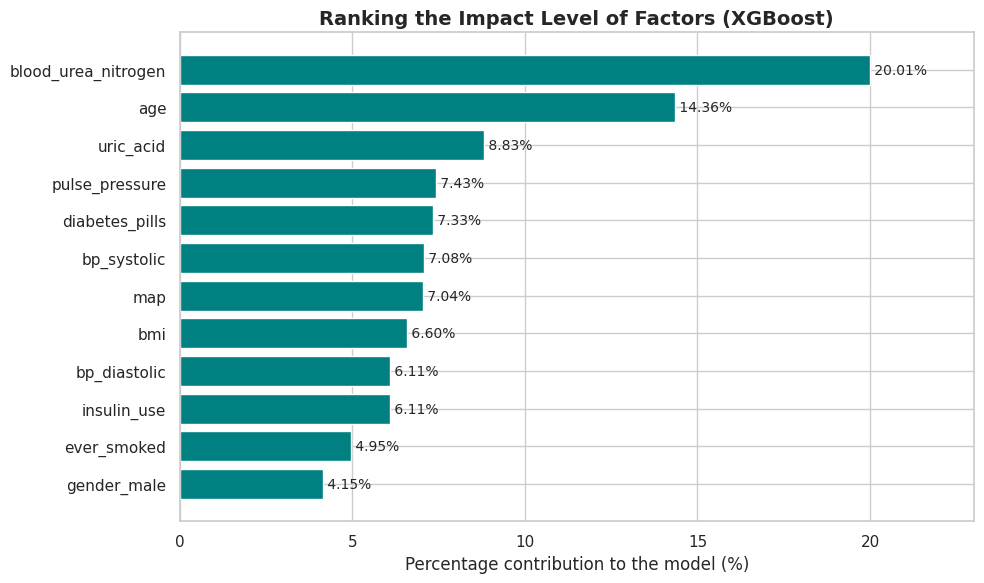

In [ ]:
# =========================================================
# TRÍCH XUẤT YẾU TỐ NGUY CƠ (TỪ LOGREG VÀ XGBOOST)
# =========================================================

# 1. BẢNG ODDS RATIO TỪ LOGISTIC REGRESSION (Giải thích rủi ro)
odds_ratios = np.exp(log_reg.coef_[0])
or_df = pd.DataFrame({'Yếu tố lâm sàng': X.columns, 'Odds Ratio': odds_ratios})
or_df = or_df.sort_values(by='Odds Ratio', ascending=False)

print("=== BẢNG ODDS RATIO (MỨC ĐỘ TĂNG NGUY CƠ) ===")
print(or_df)
print("-" * 50)
print("* Gợi ý đọc: Nếu ever_smoked có Odds Ratio = 1.3, nghĩa là người hút thuốc có rủi ro mắc CKD cao gấp 1.3 lần người không hút thuốc.\n")

# 2. VẼ BIỂU ĐỒ FEATURE IMPORTANCE TỪ XGBOOST (Xếp hạng quan trọng)
importances = xgb.feature_importances_ * 100
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Ranking the Impact Level of Factors (XGBoost)', fontsize=14, fontweight='bold')
bars = plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Percentage contribution to the model (%)', fontsize=12)

# Gắn phần trăm lên thanh biểu đồ
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f' {bar.get_width():.2f}%', va='center', ha='left', fontsize=10)

plt.xlim(0, max(importances) * 1.15)
plt.tight_layout()
plt.savefig('XGBoost_Feature_Importance.png', dpi=300)
plt.show()

/tmp/ipykernel_8462/1492237186.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


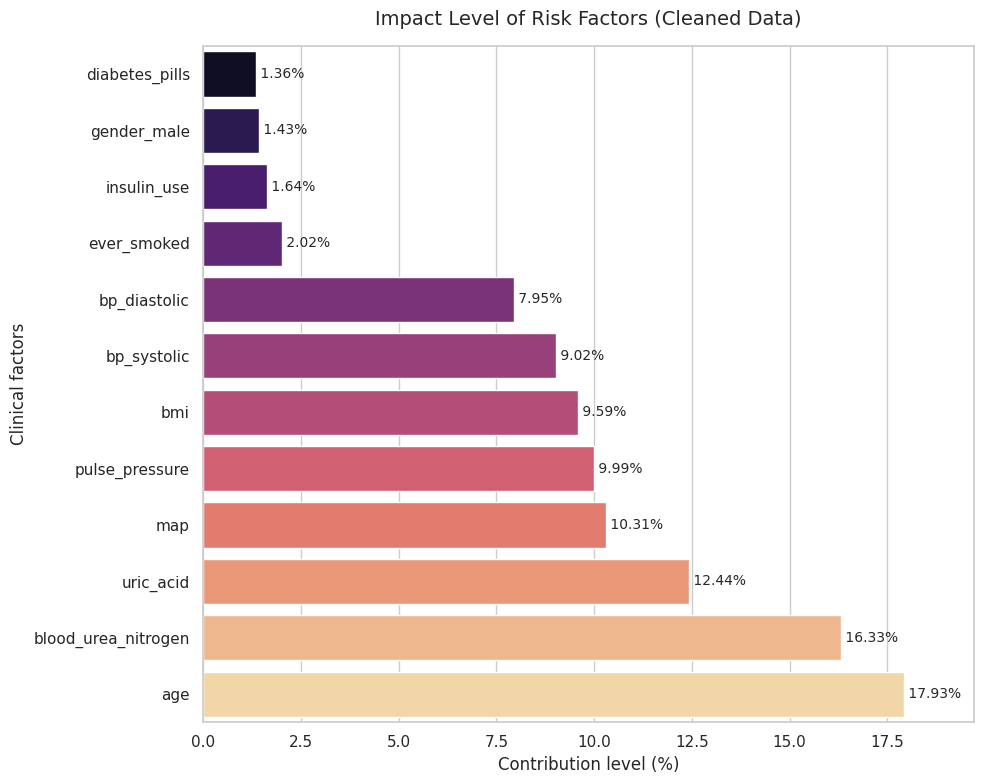

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. CHỈ CẦN ĐỌC FILE ĐÃ LÀM SẠCH TỪ CODE 1
df_clean = pd.read_csv('CKD_diabetic_cleaned.csv')

X = df_clean.drop('ckd_present', axis=1)
y = df_clean['ckd_present']

# 2. CHẠY RANDOM FOREST
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X, y)

# 3. VẼ BIỂU ĐỒ (Dạng phần trăm giống Code 2 của bạn)
importances_percent = rf.feature_importances_ * 100

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances_percent
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')

plt.title('Impact Level of Risk Factors (Cleaned Data)', fontsize=14, pad=15)
plt.xlabel('Contribution level (%)', fontsize=12)
plt.ylabel('Clinical factors', fontsize=12)

# Gắn số phần trăm lên biểu đồ
for index, value in enumerate(importance_df['Importance']):
    plt.text(value, index, f' {value:.2f}%', va='center', fontsize=10)

plt.xlim(0, importance_df['Importance'].max() * 1.1)
plt.tight_layout()
plt.savefig('feature_importance_cleaned_data.png', dpi=300)
plt.show()